In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import time
import torch
import torch.optim as optim
import numpy as np

import matplotlib.pyplot as plt
from matplotlib import cm, colors

from funcshape.testlib.surfaces import CylinderWrap, LogStepQuadratic
from funcshape.testlib.surfaces import HyperbolicParaboloid, RotationDiffeomorphism

from funcshape.surface import Surface, ComposedSurface
from funcshape.transforms import Qmap2D, SRNF
from funcshape.visual import (
    get_common_colornorm,
    plot_surface,
    plot_diffeomorphism_2d,
    save_surface_reparam,
    save_diffeomorphism_2d,
    save_error_plot
)
    
from funcshape.networks import SurfaceReparametrizer
from funcshape.layers.sinefourier import SineFourierLayer
from funcshape.loss import SurfaceDistance
from funcshape.reparametrize import reparametrize
from funcshape.logging import Logger
from funcshape.visual import get_plot_data 

In [12]:
from sklearn.manifold import Isomap
from sklearn.manifold import LocallyLinearEmbedding
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern

class PointCloudSurface(Surface):
    def __init__(self, points, uv=None, method="cubic"):
        """
        points: array of shape (N, 3) -> the point cloud in 3D
        uv: array of shape (N, 2) -> optional parameterization for each point
            If None, a default 2D projection (PCA) is used.
        method: interpolation method ('linear', 'nearest', 'cubic')
        """
        self.points = np.asarray(points)
        self.method = method

        if uv is None:
            # Project to 2D
            uv = LocallyLinearEmbedding(n_components=2).fit_transform(self.points)
            # uv = Isomap(n_components=2, n_neighbors=3).fit_transform(self.points)
            # Normalize to [0,1]^2
            uv = (uv - uv.min(0)) / (uv.max(0) - uv.min(0))
        self.uv = np.asarray(uv)

        # Build interpolation function
        kernel = 1.0 * Matern(length_scale=1.0, nu=1.5)
        self.interps = []
        for i in range(3):
            gpr = GaussianProcessRegressor(kernel=kernel, random_state=23)
            gpr.fit(self.uv, self.points[:,i])
            self.interps.append(lambda x: gpr.predict(x))
 
        # Pass callable mapping into Surface base class
        super().__init__(
            (
                lambda x: torch.tensor(self.interps[i](x.detach().cpu().numpy()), dtype=torch.float32) for i in range(3)
            )
        )

/Users/knv2/Documents/codebase/envs/funcshape/lib/python3.11/site-packages/sklearn/gaussian_process/_gpr.py:663: ConvergenceWarning: lbfgs failed to converge after 15 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
/Users/knv2/Documents/codebase/envs/funcshape/lib/python3.11/site-packages/sklearn/gaussian_process/_gpr.py:663: ConvergenceWarning: lbfgs failed to converge after 15 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
/Users/knv2/Documents/codebase/envs/funcshape/lib/python3.11/site-packages/sklearn/gaussian_process/_gpr.py:663: ConvergenceWarning: lbfgs failed to converge after 20 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-lear

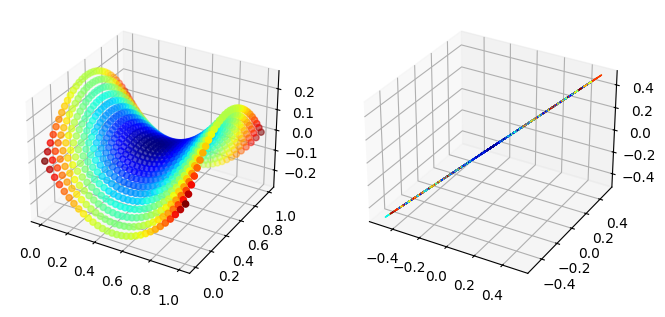

In [13]:
f_analytical = HyperbolicParaboloid()
k = 30
X, Y = torch.meshgrid((torch.linspace(0, 1, k), torch.linspace(0, 1, k)))
X, Y = X.reshape(-1, 1), Y.reshape(-1, 1)
X = torch.cat((X, Y), dim=1)

points = f_analytical(X)
f = PointCloudSurface(points)
curvature = np.asarray([f_analytical.volume_factor(p, h=1e-3).item() for p in points])

fig, axs = plt.subplots(
    1,2,
    figsize=(4*2, 4), 
    subplot_kw = {"projection":"3d"}
)
axs[0].scatter(
    points[:,0],
    points[:,1],
    points[:,2],
    c=curvature,
    cmap="jet"
)
plot_surface(f, ax=axs[1])
plt.show()

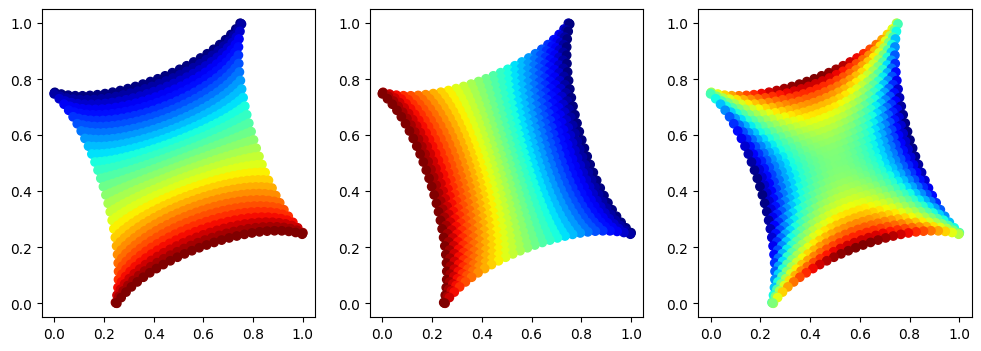

In [7]:
fig, axs = plt.subplots(1,3, figsize=(4*3, 4))
for i, ax in enumerate(axs):
    ax.scatter(f.uv[:,0], f.uv[:,1], c = points[:,i], cmap="jet")
plt.show()

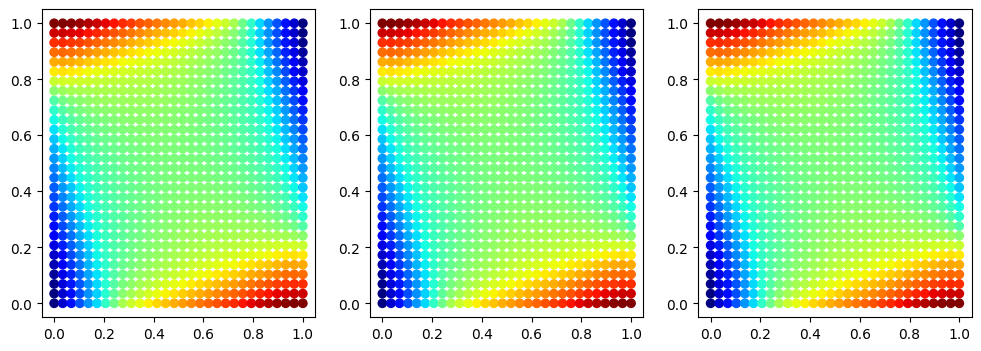

In [8]:
fig, axs = plt.subplots(1,3, figsize=(4*3, 4))
U, V = torch.meshgrid((torch.linspace(0, 1, k), torch.linspace(0, 1, k)))
U, V = U.reshape(-1, 1), V.reshape(-1, 1)

UV = torch.cat((U, V), dim=1)

Z = f(UV).detach().numpy()
for i, ax in enumerate(axs):
    ax.scatter(UV[:,0], UV[:,1], c = Z[:,i], cmap="jet")
plt.show()

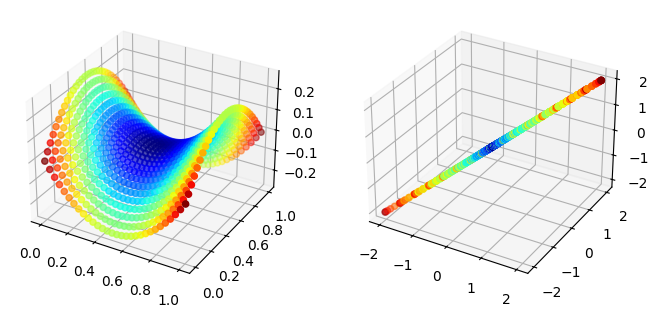

In [9]:
fig, axs = plt.subplots(
    1,2,
    figsize=(4*2, 4), 
    subplot_kw = {"projection":"3d"}
)
axs[0].scatter(
    points[:,0],
    points[:,1],
    points[:,2],
    c=curvature,
    cmap="jet"
)
axs[1].scatter(
    Z[:,0],
    Z[:,1],
    Z[:,2],
    c=curvature,
    cmap="jet"
)
plt.show()

### Registering PointCloudSurface

[Iter     1] loss: 0.000000
Finished training in 0.77580s


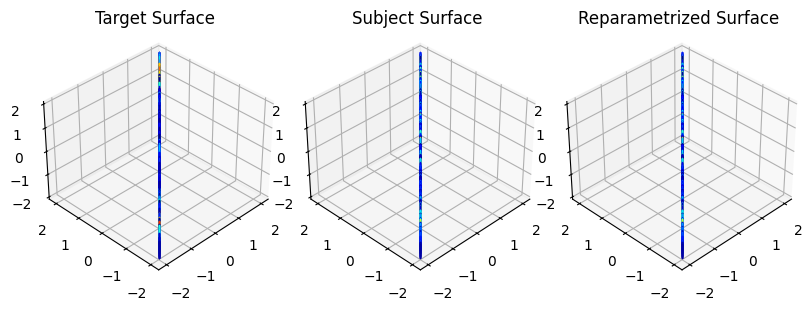

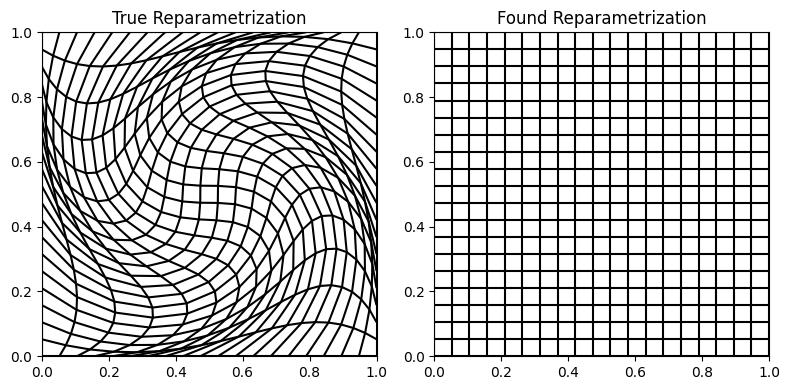

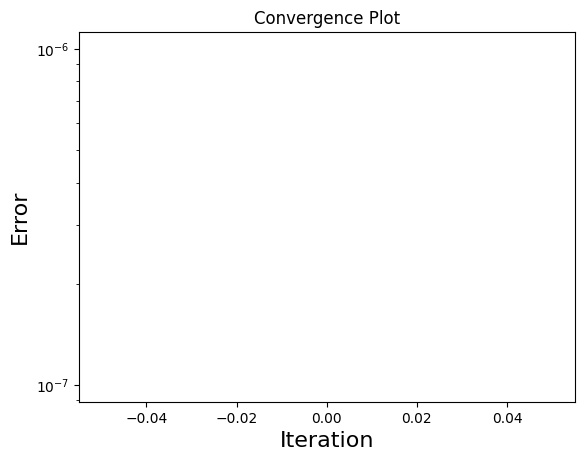

In [10]:
γ = RotationDiffeomorphism()
g = f.compose(γ)
g = ComposedSurface(f, γ)
q = SRNF(g)
r = SRNF(f)

# Use GPU capabilities? Makes small differences for small networks,
# but is significantly more scalable.
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
# device = "cpu"

# Define reparametrization-network
RN = SurfaceReparametrizer(
    [SineFourierLayer(10) for _ in range(10)]
).to(device)
loss_func = SurfaceDistance(q, r, k=32, h=1e-4).to(device)

optimizer = optim.LBFGS(RN.parameters(), max_iter=30, line_search_fn="strong_wolfe")
errors = reparametrize(RN, loss_func, optimizer, 30, Logger(1))
RN.to("cpu"), loss_func.to("cpu"); # Need on CPU for plotting.
RN.detach()

# Reparametrize f
fafter = f.compose(RN)

# Define figure path for saving
path = "../figures/surface-reparametrization-srnf"

# Create Coloring Functions for plotting
k = 32 # Points per dimension (k^2 points total)
camera = (35, 225)
norm = get_common_colornorm((f, g, fafter), k=k)

save_surface_reparam(path, f, g, RN, camera, k)
save_error_plot(path, errors)
save_diffeomorphism_2d(path, γ, RN, k=20, clear=True)

fig = plt.figure(figsize=(8, 4))
ax1 = fig.add_subplot(1, 3, 1, projection='3d')
ax2 = fig.add_subplot(1, 3, 2, projection="3d")
ax3 = fig.add_subplot(1, 3, 3, projection='3d')

plot_surface(g, ax=ax1, k=k, colornorm=norm, camera=camera)
ax1.set_title("Target Surface")
plot_surface(f, ax=ax2, k=k, colornorm=norm, camera=camera)
ax2.set_title("Subject Surface")
plot_surface(fafter, ax=ax3, k=k, colornorm=norm, camera=camera)
ax3.set_title("Reparametrized Surface")
plt.tight_layout()
plt.show()

# Plot Diffeomorphisms. 
fig = plt.figure(figsize=(8, 4))
ax = fig.add_subplot(121)
plot_diffeomorphism_2d(γ, k=20, color="k", ax=ax)
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.title("True Reparametrization")

ax = fig.add_subplot(122)
plot_diffeomorphism_2d(RN, k=20, color="k", ax=ax)
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.title("Found Reparametrization")
plt.tight_layout()
plt.show()

plt.figure()
plt.semilogy(errors)
plt.axhline(0., ls="--", c="black")
plt.ylabel("Error", fontsize=16)
plt.xlabel("Iteration", fontsize=16)
plt.title("Convergence Plot")
plt.show()

/Users/knv2/Documents/codebase/envs/funcshape/lib/python3.11/site-packages/sklearn/manifold/_isomap.py:384: UserWarning: The number of connected components of the neighbors graph is 147 > 1. Completing the graph to fit Isomap might be slow. Increase the number of neighbors to avoid this issue.
  self._fit_transform(X)
/Users/knv2/Documents/codebase/envs/funcshape/lib/python3.11/site-packages/scipy/sparse/_index.py:168: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])
/Users/knv2/Documents/codebase/envs/funcshape/lib/python3.11/site-packages/scipy/sparse/_index.py:168: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])
/Users/knv2/Documents/codebase/envs/funcshape/lib/python3.11/site-packages/scipy/sparse/_index.py:168: SparseEfficiencyWarning: Changing the sparsity stru

KeyboardInterrupt: 

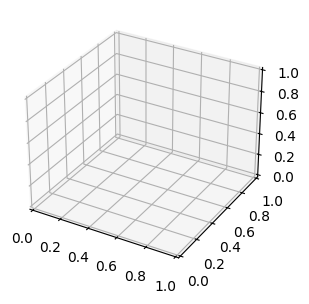

In [11]:
from funcshape.interpolation import linear_interpolate

numsteps = 7
with torch.no_grad():
    fig = plt.figure(figsize=(7*4, 4))
    for i, h in enumerate(linear_interpolate(lambda x: g(RN(x)), f, numsteps)):
        ax = fig.add_subplot(1, numsteps, i+1, projection="3d")
        plot_surface(PointCloudSurface(h(X).numpy()), k=20, ax = ax)
    plt.tight_layout()
    plt.show()